<a href="https://maestriasydiplomados.tec.mx/posgrados/maestria-en-inteligencia-artificial-aplicada"><img src="logo_MR4010.png"></a>
<h1> <div align="center"> Dr. David Antonio-Torres</div> </h1>

# DETECCION DE BORDES CON OPENCV

## Entorno de ejecución y referencias

🔗 **Repositorio GitHub:** [https://github.com/joelbecv/MNA_WORKSPACE](https://github.com/joelbecv/MNA_WORKSPACE)  
📁 **Archivo:** `2.3_detección_de_bordes.ipynb`

### ¿Dónde puedo correr este notebook?

| Entorno | Estado | Tiempo estimado |
|---------|--------|-----------------|
| 💻 Mac M5 (local) | ✅ Funciona | < 1 min |
| ☁️ Google Colab | ✅ Funciona | < 1 min |


# Se cargan las bibliotecas necesarias

In [3]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2
%matplotlib inline

# Esta es la imagen de prueba que se usará en este Notebook
#### https://learnopencv.com/wp-content/uploads/2021/06/input_image-1.jpg

![Imagen](input_image-1.jpg)

# Se define una función adecuada para mostrar las imágenes procesadas en línea con el código

In [1]:
def display_img(img):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap='gray')

# Se carga la imagen en escala de grises, necesaria para la detección de bordes

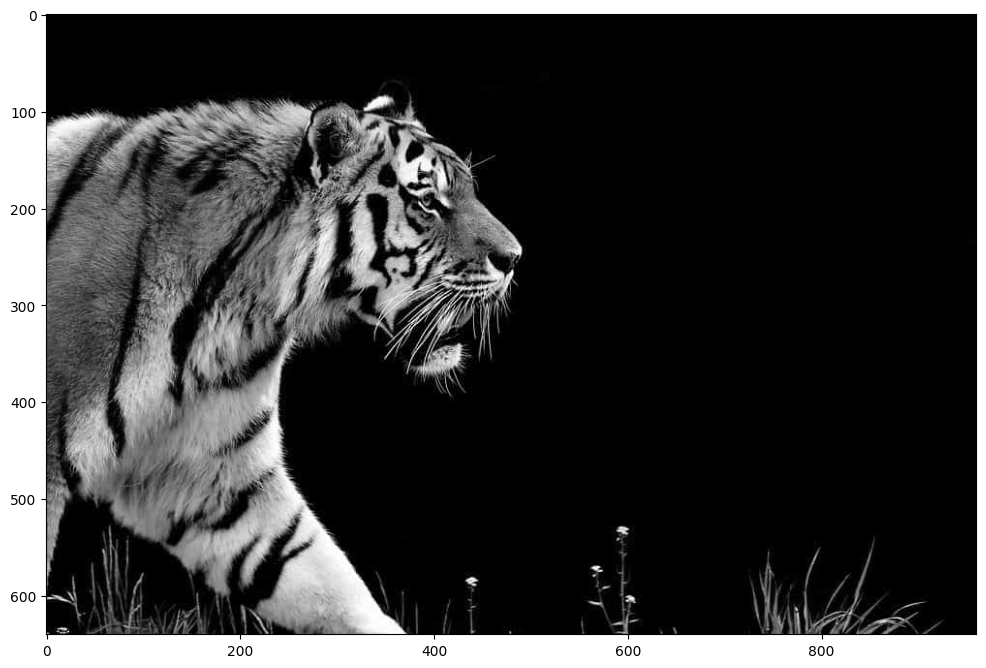

In [4]:
img = cv2.imread('input_image-1.jpg',cv2.IMREAD_GRAYSCALE)
display_img(img)

# Es requisito aplicar a la imagen un filtrado previo para eliminar componentes de alta frecuencia y facilitar la detección de bordes

In [5]:
# el tamaño del kernel debe ser impar
# sigmaX y sigmaY son las desviaciones estándar en las direcciones indicadas
img_blur = cv2.GaussianBlur(img,(3,3), sigmaX=0, sigmaY=0) 

# Se muestra la detección de bordes con Sobel en el eje X

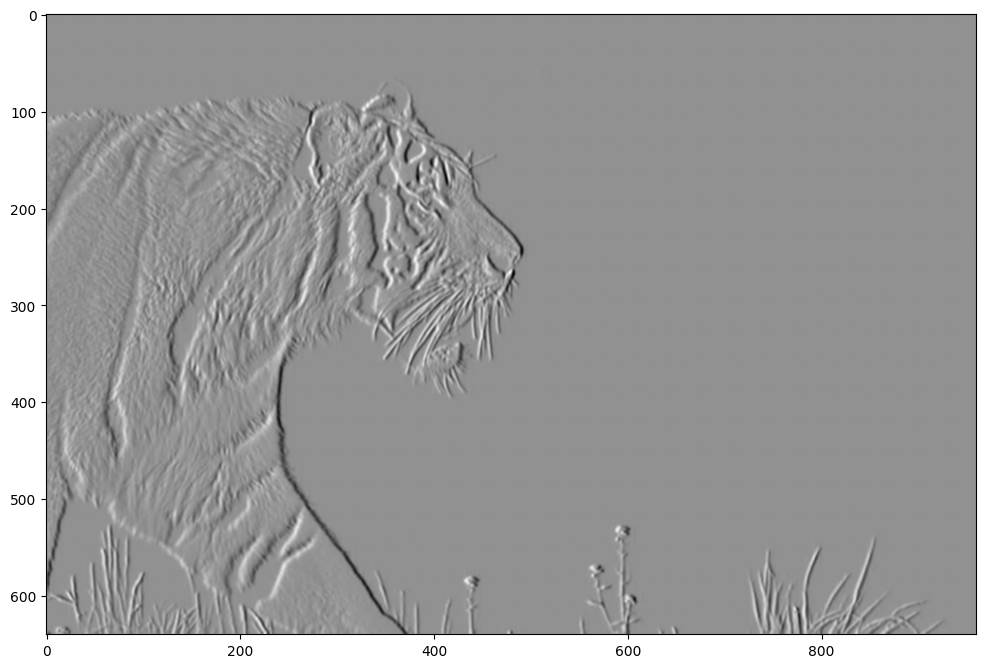

In [6]:
# src indica la imagen sobre la cual se realiza el procesamiento
# ddepth indica la resolución numérica del algoritmo, el cual es punto flotante de 64 bits
# dx = 1 y dy = 0 indica que se calculará la primera derivada sobre el eje x
# ksize indica el tamaño del kernel a usar
sobelx_img = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=5)
display_img(sobelx_img)

# Se muestra la detección de bordes con Sobel en el eje Y

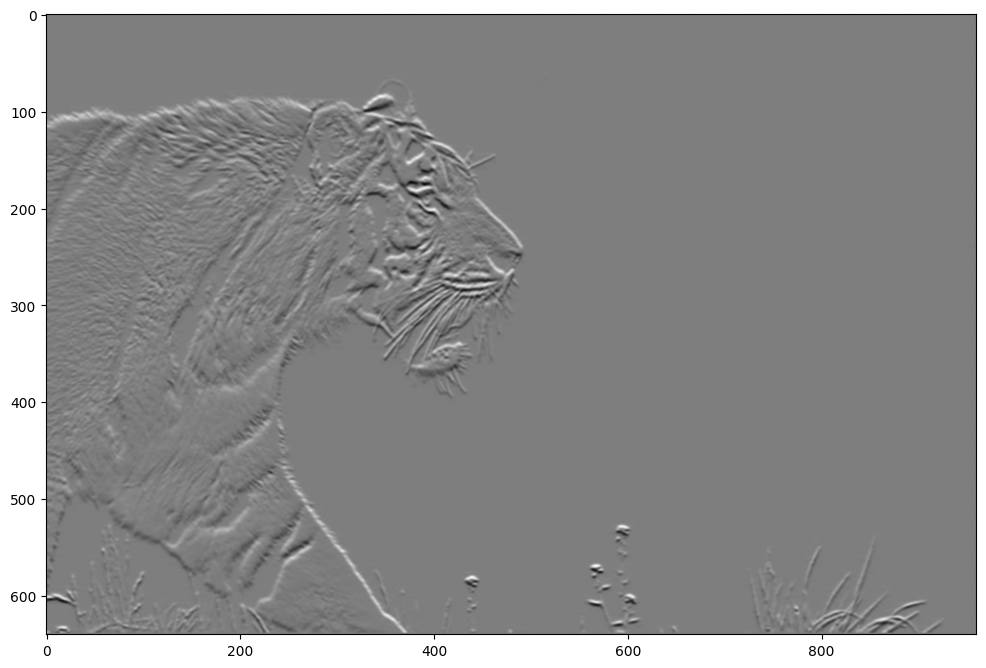

In [7]:
# dx = 0 y dy = 1 indica que se calculará la primera derivada sobre el eje y
sobely_img = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=5)
display_img(sobely_img)

# Se muestra la detección de bordes con Sobel en ambos ejes

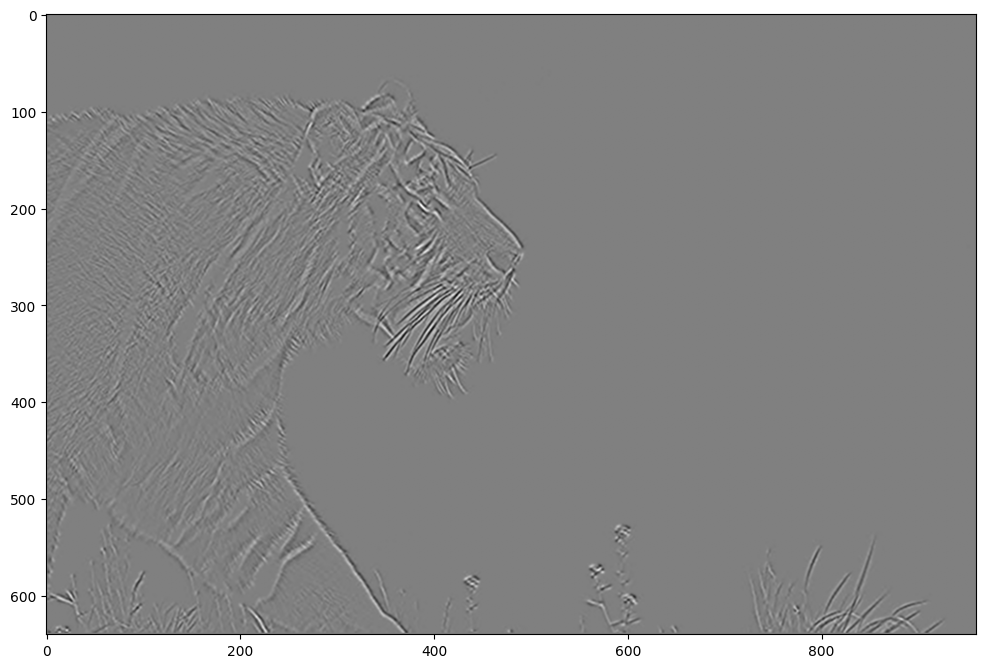

In [8]:
# dx = 1 y dy = 1 indica que se calculará la primera derivada sobre ambos ejes
sobelxy_img = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5)
display_img(sobelxy_img)

# El método Laplacian aplica el operador Laplaciano (segunda derivada) en ambos ejes
### Internamente, el método utiliza el operador Sobel

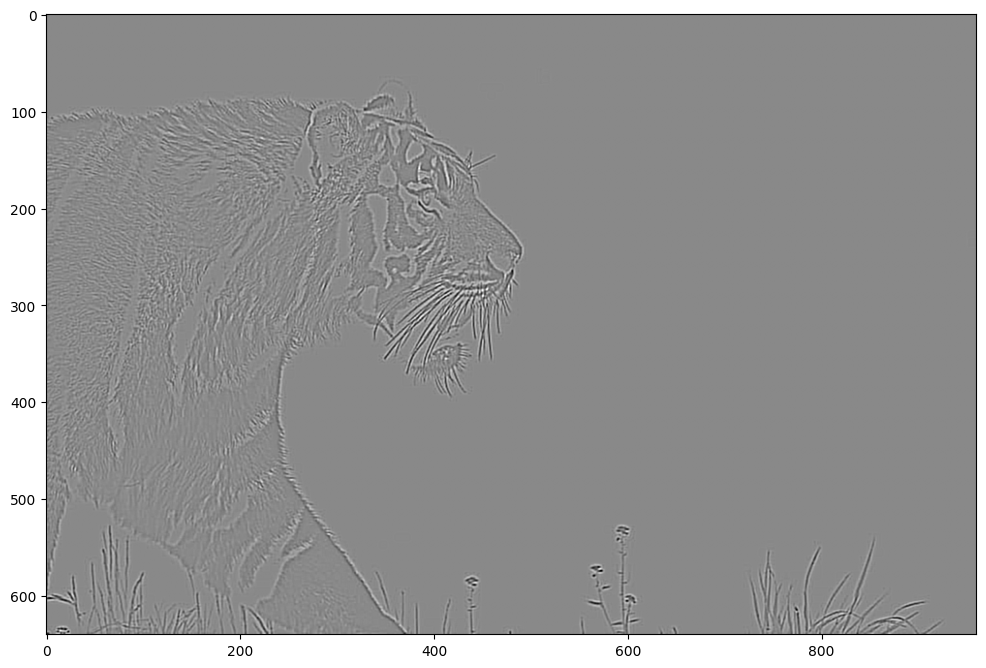

In [9]:
# ddepth y ksize aplican igual que en el método Sobel
laplacian_img = cv2.Laplacian(src=img_blur, ddepth=cv2.CV_64F, ksize = 3)
display_img(laplacian_img)

# El método de Canny es uno de los preferidos por su robustez y precisión
### 1. Reducción de ruido
### 2. Cálculo del gradiente de intensidad de la imagen
### 3. Supresión de bordes falsos
### 4. Umbralización con histéresis
### https://learnopencv.com/edge-detection-using-opencv/

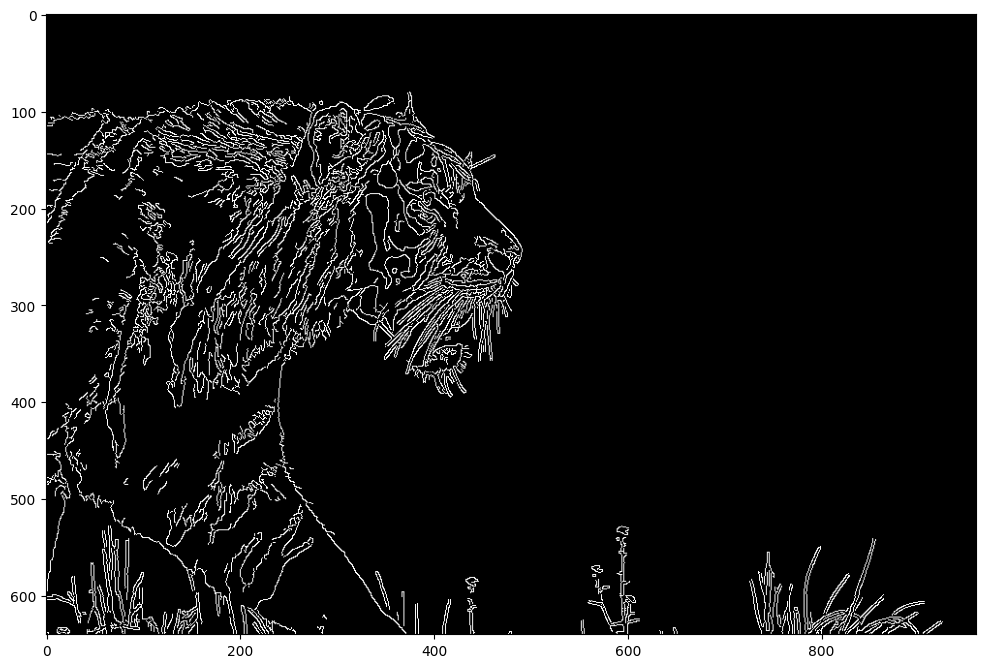

In [10]:
# pixeles por debajo de threshold1 no son considerados bordes
# pixles por encima de thresholds2 son considerados bordes
# pixeles entre ambos thresholds se consideran bordes si se encuentran unidos a pixeles considerados como bordes
canny_img = cv2.Canny(image=img_blur, threshold1=100, threshold2=200) 
display_img(canny_img)

# Gracias por la atención